In [15]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
df = pd.read_csv(
    "../data/citibike_weather_daily.csv",
    parse_dates=["ride_date"]
)

df.head()

,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month
0,2013-07-01,16650,16.309988,74.8,78.1,73.4,7.8,0.00,Monday,7
1,2013-07-02,22745,15.968826,76.1,82.9,73.0,8.0,0.73,Tuesday,7
2,2013-07-03,21864,16.238808,78.5,84.9,73.9,8.8,0.06,Wednesday,7
3,2013-07-04,22326,21.218474,82.0,91.0,73.9,8.6,0.96,Thursday,7
4,2013-07-05,21842,18.040443,84.4,93.0,75.9,9.0,0.00,Friday,7


In [17]:
df["year"] = df["ride_date"].dt.year
df["month"] = df["ride_date"].dt.month
df["day_of_week"] = df["ride_date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [18]:
X = df.drop(columns=["ride_date", "num_rides"])
y = df["num_rides"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = model.predict(X_test)

y_pred[:5]

array([31609.97829072, 27144.21095331, 33239.02909173, 55260.04929091,
        1795.34563179])

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 6773.270494301671
RMSE: 8764.860621255842
R²: 0.7440082113036124


In [24]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
8,year,5966.548094
7,month,1123.943037
1,temp_f,375.050933
0,avg_duration_min,327.190669
2,max_temp_f,272.243850
6,day_of_week,164.295496
5,precip_in,-11.867421
3,min_temp_f,-152.926641
4,wind_speed_knots,-444.155193
9,is_weekend,-8606.130580


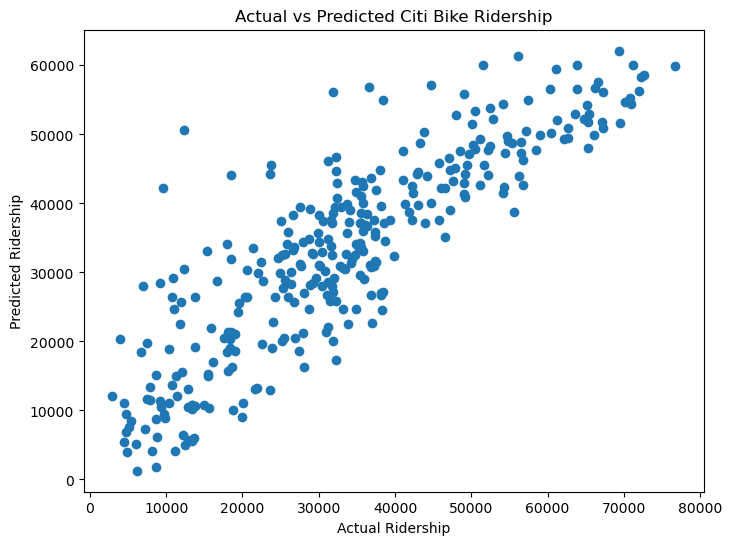

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Actual vs Predicted Citi Bike Ridership")

plt.show()

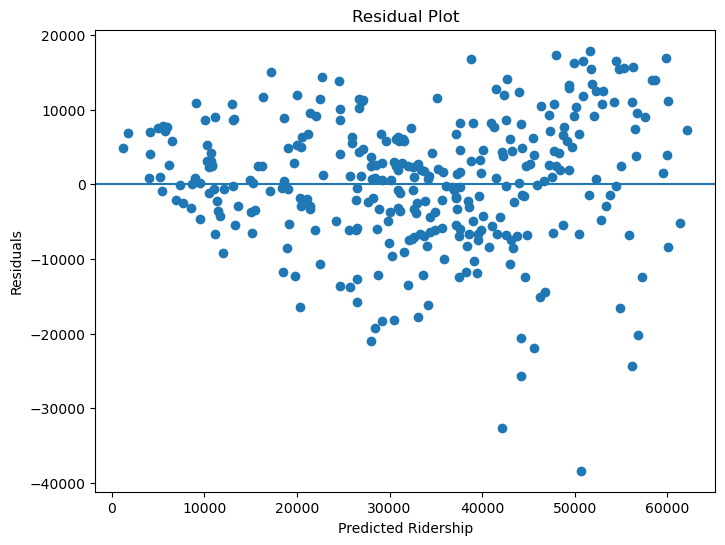

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0
)

plt.xlabel("Predicted Ridership")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [27]:
from sklearn.ensemble import RandomForestRegressor

In [28]:
#Create the random forest model and train the model 
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [29]:
#Make the first prediction an d check it
rf_pred = rf_model.predict(X_test)

rf_pred[:5]

array([30731.96, 35182.82, 27777.39, 65512.07,  9158.19])

In [30]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)


print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 4846.998633540372
Random Forest RMSE: 7008.962132543223
Random Forest R²: 0.8363019773539729


In [31]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R²": [r2, rf_r2]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,6773.270494,8764.860621,0.744008
1,Random Forest,4846.998634,7008.962133,0.836302


In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,temp_f,0.325085
8,year,0.306902
2,max_temp_f,0.107733
3,min_temp_f,0.080460
0,avg_duration_min,0.064647
7,month,0.030473
6,day_of_week,0.026805
5,precip_in,0.023885
4,wind_speed_knots,0.021809
9,is_weekend,0.012202


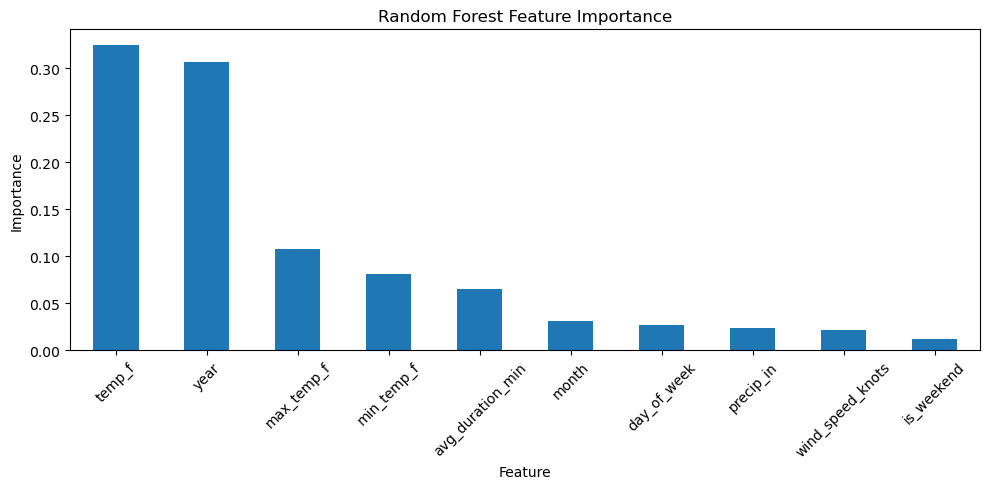

In [33]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
### Conclusion In this project, I built and compared two machine learning models—Linear Regression and Random Forest—to predict daily Citi Bike ridership using weather conditions and date-related features. 
# After evaluating both models, the Random Forest model produced better overall results, suggesting that it was more effective at capturing the complex relationships between weather patterns and bike usage. 
# I also analyzed feature importance to better understand which variables had the greatest impact on ridership. This helped explain how factors such as temperature, precipitation, and the time of year influence the number of daily rides.
# Overall, this project demonstrated the complete machine learning workflow, from exploring and preparing the data to training, evaluating, and interpreting predictive models. 
# It also highlighted how data-driven insights can be used to better understand customer behavior and support decision-making.
